<p style="text-align:center;">
    <img src='https://repository-images.githubusercontent.com/223699949/0601d980-5912-11eb-8486-3237a1e3c4cf' width="1000">
</p>

# Credit Card Fraud Detection

# Credit Card Fraud Detection

This project focuses on detecting fraudulent credit card transactions using Machine Learning techniques. The dataset contains real-world credit card transactions made by European cardholders and is highly imbalanced, where fraudulent transactions represent only a very small percentage of the total records.

## Dataset Description

The dataset contains 31 features, including anonymized variables obtained through PCA transformation, along with transaction time, transaction amount, and the target class.

### Features

**Time** - The number of seconds elapsed between this transaction and the first transaction in the dataset.

**V1 – V28** - Numerical features obtained using Principal Component Analysis (PCA) to protect sensitive customer information.

**Amount** - The transaction amount. This feature can be used for cost-sensitive learning and fraud analysis.

**Class** - The target variable indicating whether a transaction is fraudulent or legitimate.

* **0** → Legitimate Transaction (Non-Fraud)
* **1** → Fraudulent Transaction (Fraud)

## Project Objective

The main objective of this project is to build an effective machine learning model capable of identifying fraudulent credit card transactions while minimizing false negatives and maximizing fraud detection performance.

## Challenges

One of the major challenges in this dataset is the severe class imbalance problem. Fraudulent transactions account for less than 1% of all transactions, making it difficult for standard machine learning algorithms to accurately detect fraud cases.

To address this issue, data balancing techniques such as SMOTE (Synthetic Minority Over-sampling Technique) are applied before training the models.

## Models Used

Several machine learning models are evaluated and compared, including:

* Logistic Regression
* Random Forest Classifier
* Voting Classifier
* XGBoost (Bonus)

The models are evaluated using metrics suitable for imbalanced classification problems, such as:

* Precision
* Recall
* F1-Score
* PR-AUC
* Confusion Matrix

The best-performing model is selected based on its ability to accurately identify fraudulent transactions while maintaining strong overall classification performance.


 | Column | Meaning                                                                       | Why is it important?                                      |
| ------ | ----------------------------------------------------------------------------- | --------------------------------------------------------- |
| Time   | Time elapsed between the transaction and the first transaction in the dataset | May help identify unusual transaction timing patterns     |
| V1     | PCA transformed feature 1                                                     | Contains hidden information useful for fraud detection    |
| V2     | PCA transformed feature 2                                                     | Helps distinguish fraudulent from legitimate transactions |
| V3     | PCA transformed feature 3                                                     | Captures important transaction characteristics            |
| V4     | PCA transformed feature 4                                                     | Contributes to fraud classification                       |
| V5     | PCA transformed feature 5                                                     | May reveal abnormal transaction behavior                  |
| V6     | PCA transformed feature 6                                                     | Useful for identifying suspicious patterns                |
| V7     | PCA transformed feature 7                                                     | Contains anonymized transaction information               |
| V8     | PCA transformed feature 8                                                     | Supports model prediction                                 |
| V9     | PCA transformed feature 9                                                     | Helps separate fraud and non-fraud transactions           |
| V10    | PCA transformed feature 10                                                    | Important numerical feature for classification            |
| V11    | PCA transformed feature 11                                                    | Contributes to detecting fraudulent behavior              |
| V12    | PCA transformed feature 12                                                    | Contains transformed transaction information              |
| V13    | PCA transformed feature 13                                                    | Useful for model learning                                 |
| V14    | PCA transformed feature 14                                                    | Strongly related to fraud detection in many cases         |
| V15    | PCA transformed feature 15                                                    | Supports classification performance                       |
| V16    | PCA transformed feature 16                                                    | Helps identify transaction anomalies                      |
| V17    | PCA transformed feature 17                                                    | Important fraud-related feature                           |
| V18    | PCA transformed feature 18                                                    | Provides additional transaction patterns                  |
| V19    | PCA transformed feature 19                                                    | Supports fraud prediction                                 |
| V20    | PCA transformed feature 20                                                    | Contains anonymized information                           |
| V21    | PCA transformed feature 21                                                    | Useful for classification                                 |
| V22    | PCA transformed feature 22                                                    | Helps distinguish transaction types                       |
| V23    | PCA transformed feature 23                                                    | Contributes to prediction accuracy                        |
| V24    | PCA transformed feature 24                                                    | Contains hidden transaction characteristics               |
| V25    | PCA transformed feature 25                                                    | Useful for model training                                 |
| V26    | PCA transformed feature 26                                                    | Supports fraud detection                                  |
| V27    | PCA transformed feature 27                                                    | Helps identify unusual transactions                       |
| V28    | PCA transformed feature 28                                                    | Additional transformed feature for prediction             |
| Amount | Transaction amount                                                            | Large or unusual amounts may indicate fraud               |
| Class  | Transaction label (0 = Normal, 1 = Fraud)                                     | **Target variable that the model aims to predict**        |


The features V1–V28 were obtained using Principal Component Analysis (PCA) to protect sensitive customer information. Therefore, their original meanings are not available, but they remain highly informative for detecting fraudulent transactions.


## Exploration

In [473]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
  

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
df = pd.read_csv(
    r'D:\zageng\CreditCardFraudDetection\src\data\splits\split\train.csv'
)
df.head()



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,119191.0,2.052427,-0.133236,-1.740621,0.277935,0.337999,-0.826933,0.334629,-0.227039,0.267655,...,-0.006518,0.121300,0.037733,-0.356498,0.147822,0.569149,-0.103929,-0.091958,8.73,0
1,71750.0,1.220356,-0.159191,-0.444349,-0.094437,0.104457,-0.345790,0.170867,-0.094996,0.187572,...,-0.088775,-0.364654,-0.140851,-0.707308,0.415661,1.087767,-0.102532,-0.008335,59.95,0
2,151977.0,0.892824,-1.440698,-0.637940,3.912871,0.099291,2.433288,-0.308891,0.603227,-0.113826,...,0.484969,0.487304,-0.122694,-0.598803,-0.594563,0.062841,-0.033426,0.038254,460.65,0
3,55709.0,-3.146021,2.247634,0.901397,0.146162,-2.109360,-0.148312,-1.533191,2.073663,0.499394,...,0.050567,-0.037019,0.107000,0.392857,0.303597,0.379544,-0.148990,0.074965,4.78,0
4,66654.0,1.194996,-0.007495,0.301285,0.750199,-0.297494,-0.405836,0.060410,-0.150482,0.400860,...,-0.234931,-0.545566,-0.089418,-0.064036,0.527305,0.294221,-0.025980,0.015637,44.31,0


In [475]:
print(df["Class"].head())
print(df["Class"].unique())
print(df["Class"].dtype)

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64
[0 1]
int64


In [476]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170884 entries, 0 to 170883
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    170884 non-null  float64
 1   V1      170884 non-null  float64
 2   V2      170884 non-null  float64
 3   V3      170884 non-null  float64
 4   V4      170884 non-null  float64
 5   V5      170884 non-null  float64
 6   V6      170884 non-null  float64
 7   V7      170884 non-null  float64
 8   V8      170884 non-null  float64
 9   V9      170884 non-null  float64
 10  V10     170884 non-null  float64
 11  V11     170884 non-null  float64
 12  V12     170884 non-null  float64
 13  V13     170884 non-null  float64
 14  V14     170884 non-null  float64
 15  V15     170884 non-null  float64
 16  V16     170884 non-null  float64
 17  V17     170884 non-null  float64
 18  V18     170884 non-null  float64
 19  V19     170884 non-null  float64
 20  V20     170884 non-null  float64
 21  V21     170884 non-nu

In [477]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,...,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000
mean,94966.107886,-0.001070,-0.000904,-0.002722,-0.002603,0.000151,0.000779,-0.000811,-0.002327,-0.000622,...,0.000957,0.000056,0.000475,-0.000894,-0.000593,-0.000738,0.000404,0.000422,88.511723,0.001785
std,47464.723773,1.958944,1.650481,1.521820,1.416490,1.394123,1.338331,1.260122,1.208709,1.098393,...,0.743974,0.726681,0.620647,0.605148,0.521128,0.481720,0.404540,0.314973,256.737144,0.042210
min,0.000000,-46.855047,-63.344698,-48.325589,-5.683171,-113.743307,-23.496714,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-36.666000,-2.836627,-7.081325,-2.604551,-9.895244,-15.430084,0.000000,0.000000
25%,54348.000000,-0.922071,-0.599127,-0.896376,-0.848978,-0.691840,-0.768986,-0.554440,-0.209596,-0.642036,...,-0.228068,-0.542831,-0.161063,-0.354552,-0.318057,-0.327631,-0.070719,-0.053019,5.637500,0.000000
50%,84923.500000,0.016603,0.065839,0.177007,-0.020895,-0.054185,-0.274228,0.040417,0.021461,-0.051777,...,-0.029547,0.006488,-0.010688,0.040433,0.016916,-0.051262,0.001520,0.011216,22.020000,0.000000
75%,139404.000000,1.316250,0.802518,1.028302,0.738812,0.612154,0.400359,0.569221,0.326026,0.595095,...,0.186681,0.528971,0.147814,0.437888,0.350188,0.240718,0.091713,0.078480,77.650000,0.000000
max,172792.000000,2.451888,22.057729,4.226108,16.875344,34.099309,73.301626,120.589494,18.282168,10.392889,...,27.202839,10.503090,22.528412,4.584549,6.070850,3.517346,31.612198,16.129609,25691.160000,1.000000


Dataset Shape

In [478]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 170884
Columns : 31


### Check missing

In [479]:
df.isna().sum().sum()

np.int64(0)

### Check Dublicates

In [480]:
df.duplicated().sum()

np.int64(448)

In [481]:
df[df.duplicated()].shape

(448, 31)

In [482]:
df[df.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
1252,111137.0,2.103683,0.030503,-1.438682,0.328226,0.350531,-0.731849,0.022085,-0.319948,2.155384,...,0.087941,0.618465,-0.001470,0.418124,0.344582,-0.473183,-0.027784,-0.057568,1.00,0
3262,163152.0,-1.203617,1.574009,2.889277,3.381404,1.538663,3.698747,0.560211,-0.150911,0.124136,...,-0.366727,0.522223,-0.357329,-0.870174,-0.134166,0.327019,-0.042648,-0.855262,1.51,0
4204,122075.0,-1.724438,1.573767,-1.873367,-0.899698,-3.750201,1.042587,4.263032,-0.160163,-0.310287,...,-0.298759,-0.033427,-0.075863,0.061388,-0.015207,-0.101647,0.540640,-0.167113,799.00,0
9492,39897.0,1.159796,-0.222744,1.126880,0.671504,-0.874117,0.209904,-0.733882,0.241439,0.694125,...,-0.061124,-0.019113,-0.022183,0.051718,0.267667,0.319198,0.012423,0.013990,9.90,0
11566,163152.0,-1.196037,1.585949,2.883976,3.378471,1.511706,3.717077,0.585362,-0.156001,0.122648,...,-0.370294,0.524395,-0.355170,-0.869790,-0.133198,0.327804,-0.035702,-0.858197,7.56,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168798,85319.0,-5.536010,3.724987,-1.530908,-0.384255,-1.766212,-0.707323,-0.716810,1.635694,2.025584,...,-0.545904,-0.595967,0.106310,-0.131433,0.628978,0.176681,-0.468094,-0.281975,12.98,0
169129,43153.0,-2.086016,2.203265,1.654339,2.941050,-1.683045,0.529728,-1.352162,1.793449,-0.723686,...,0.216444,0.567241,-0.035345,0.370201,0.157378,0.440341,0.210230,0.090558,0.76,0
169586,64936.0,1.150005,-0.058591,0.372711,-0.170626,-0.390476,-0.488250,-0.048794,-0.019526,-0.169624,...,-0.115453,-0.362786,0.123086,0.297409,0.052626,0.841497,-0.075286,-0.001377,29.00,0
170160,68780.0,0.488552,-0.922367,1.673494,3.003203,-1.465758,0.749788,-0.700551,0.383919,0.511891,...,0.371627,0.606800,-0.222559,0.405858,0.080003,0.148637,0.022034,0.087126,282.98,0


### Check Outlier

In [483]:
columns = df.columns

outlier_features = []

for col in columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    iqr = q3-q1

    lower_pound = q1-1.5*iqr
    upper_pound = q3+1.5*iqr
    mask = df[(df[col]<lower_pound) | (df[col]>upper_pound)]
    if not mask.empty:
        outlier_features.append([col, mask.shape[0]])
print(outlier_features)

[['V1', 4263], ['V2', 8146], ['V3', 2038], ['V4', 6811], ['V5', 7440], ['V6', 13759], ['V7', 5403], ['V8', 14697], ['V9', 5037], ['V10', 5727], ['V11', 464], ['V12', 9258], ['V13', 2000], ['V14', 8425], ['V15', 1726], ['V16', 4972], ['V17', 4428], ['V18', 4585], ['V19', 6184], ['V20', 16682], ['V21', 8845], ['V22', 773], ['V23', 11186], ['V24', 2857], ['V25', 3211], ['V26', 3315], ['V27', 23259], ['V28', 18055], ['Amount', 18906], ['Class', 305]]


In [484]:
print(df["Class"].head())
print(df["Class"].unique())
print(df["Class"].dtype)

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64
[0 1]
int64


print(df["Class"].head())
print(df["Class"].unique())
print(df["Class"].dtype)

In [485]:
feats = df.select_dtypes(np.number).columns

for feat in feats:
    q1 = df[feat].quantile(0.25)
    q3 = df[feat].quantile(0.75)
    iqr = q3-q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    mask = df[ (df[feat] < lower)  | (df[feat] > upper) ]
    if not mask.empty:
        print(f'{feat} has outlier {len(mask)}')



V1 has outlier 4263
V2 has outlier 8146
V3 has outlier 2038
V4 has outlier 6811
V5 has outlier 7440
V6 has outlier 13759
V7 has outlier 5403
V8 has outlier 14697
V9 has outlier 5037
V10 has outlier 5727
V11 has outlier 464
V12 has outlier 9258
V13 has outlier 2000
V14 has outlier 8425
V15 has outlier 1726
V16 has outlier 4972
V17 has outlier 4428
V18 has outlier 4585
V19 has outlier 6184
V20 has outlier 16682
V21 has outlier 8845
V22 has outlier 773
V23 has outlier 11186
V24 has outlier 2857
V25 has outlier 3211
V26 has outlier 3315
V27 has outlier 23259
V28 has outlier 18055
Amount has outlier 18906
Class has outlier 305


In [487]:
feats = df.drop("Class", axis=1).columns
print(df.shape)

for feat in feats:
    q1 = df[feat].quantile(0.25)
    q3 = df[feat].quantile(0.75)
    iqr = q3-q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    df[feat] = np.clip(df[feat], lower, upper)

    


(170884, 31)


In [488]:
print(df["Class"].head())
print(df["Class"].unique())
print(df["Class"].dtype)

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64
[0 1]
int64


the data has 56960 Example and 31 Feature

the data is clean, there is no missing or Nan

there is 62 duplicate example

Time Feature show the secends between the first transaction and each transaction

from V1 to V28 it's alredy scaled

Amount show the amount of transactions happen in this time

The data contain outlier examples

# (2) Data Cleaning

In [489]:
df.drop_duplicates(inplace=True)

In [490]:
columns = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
        'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
        'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


for col in columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    iqr = q3-q1

    lower_pound = q1-1.5*iqr
    upper_pound = q3+1.5*iqr
    df[col] = np.where(df[col]<lower_pound, lower_pound,np.where(df[col]>upper_pound, upper_pound, df[col]))

## EDA

In [491]:
def info(col):
    print("min", df[col].min())
    print("max", df[col].max())
    print("STD", df[col].std())
    print("Skewness", df[col].skew())
    len_unique = len(df[col].value_counts())
    print(f'Unique value counts: {len_unique}')
    if len_unique < 12:
        print(df[col].value_counts())


In [492]:
def primary_col_info(col:pd.DataFrame):
    print(f'Value Counts {col.value_counts()}')
    print(f'Minimum {col.min()}, Maximum {col.max()}')
    print(f'Skewness {col.skew()}')

In [493]:
from sklearn.manifold import TSNE

def visualize(x,y):
    tsne = TSNE(n_components=2)
    x_embeded = tsne.fit_transform(x)
    plt.scatter(x_embeded[:,0], x_embeded[:,1],c=y)
    plt.colorbar()
    plt.show()

### Target Variable Analysis

In [494]:
primary_col_info(df['Class'])

Value Counts Class
0    170139
1       297
Name: count, dtype: int64
Minimum 0, Maximum 1
Skewness 23.89289392020984


In [495]:
Y = df.iloc[:, -1]
Y

0         0
1         0
2         0
3         0
4         0
         ..
170879    0
170880    0
170881    0
170882    0
170883    0
Name: Class, Length: 170436, dtype: int64

In [496]:
info("Class")


min 0
max 1
STD 0.04170807094320435
Skewness 23.89289392020984
Unique value counts: 2
Class
0    170139
1       297
Name: count, dtype: int64


In [497]:
threshold_one = df[df['Class']==1].shape[0]/df[df['Class']==0].shape[0]
threshold_one

0.0017456315130569711

the data is higly piased across normal transaction
only 0.00157 are fraud transaction

* Fraud vs Normal

In [498]:
df["Class"].value_counts()

Class
0    170139
1       297
Name: count, dtype: int64

1. الداتا غير متوازنة (Imbalanced Dataset)
* العمليات العادية ---->  (Class = 0) = 170,579 
* عمليات الاحتيال ------>    (Class = 1) = 305 فقط

يعني الاحتيال يمثل نسبة صغيرة جدًا.

**Percentage**

In [499]:
df["Class"].value_counts(normalize=True)*100

Class
0    99.825741
1     0.174259
Name: proportion, dtype: float64

2. لا يمكن الاعتماد على Accuracy فقط

فهيحقق Accuracy عالية جدًا رغم أنه فشل في اكتشاف أي عملية احتيال.

لذلك سنستخدم:

Precision
Recall
F1-Score
PR-AUC

بدل الاعتماد على Accuracy فقط.

**Visualization**

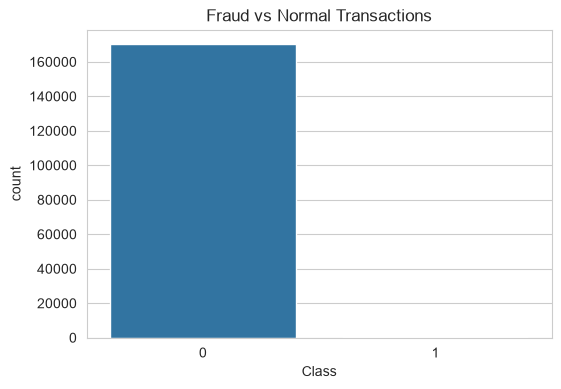

In [500]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Fraud vs Normal Transactions")
plt.show()

من الـ Count Plot نلاحظ أن:

* العمود الخاص بـ Class=0 ضخم جدًا.
* العمود الخاص بـ Class=1 صغير جدًا.

وهذا يؤكد وجود Class Imbalance.

The target variable analysis revealed a severe class imbalance problem. Legitimate transactions represent approximately 99.82% of the dataset, while fraudulent transactions account for only 0.18%. Therefore, special techniques such as SMOTE and evaluation metrics like Recall, F1-Score, and PR-AUC are required to effectively detect fraudulent transactions.

**Vs Features**

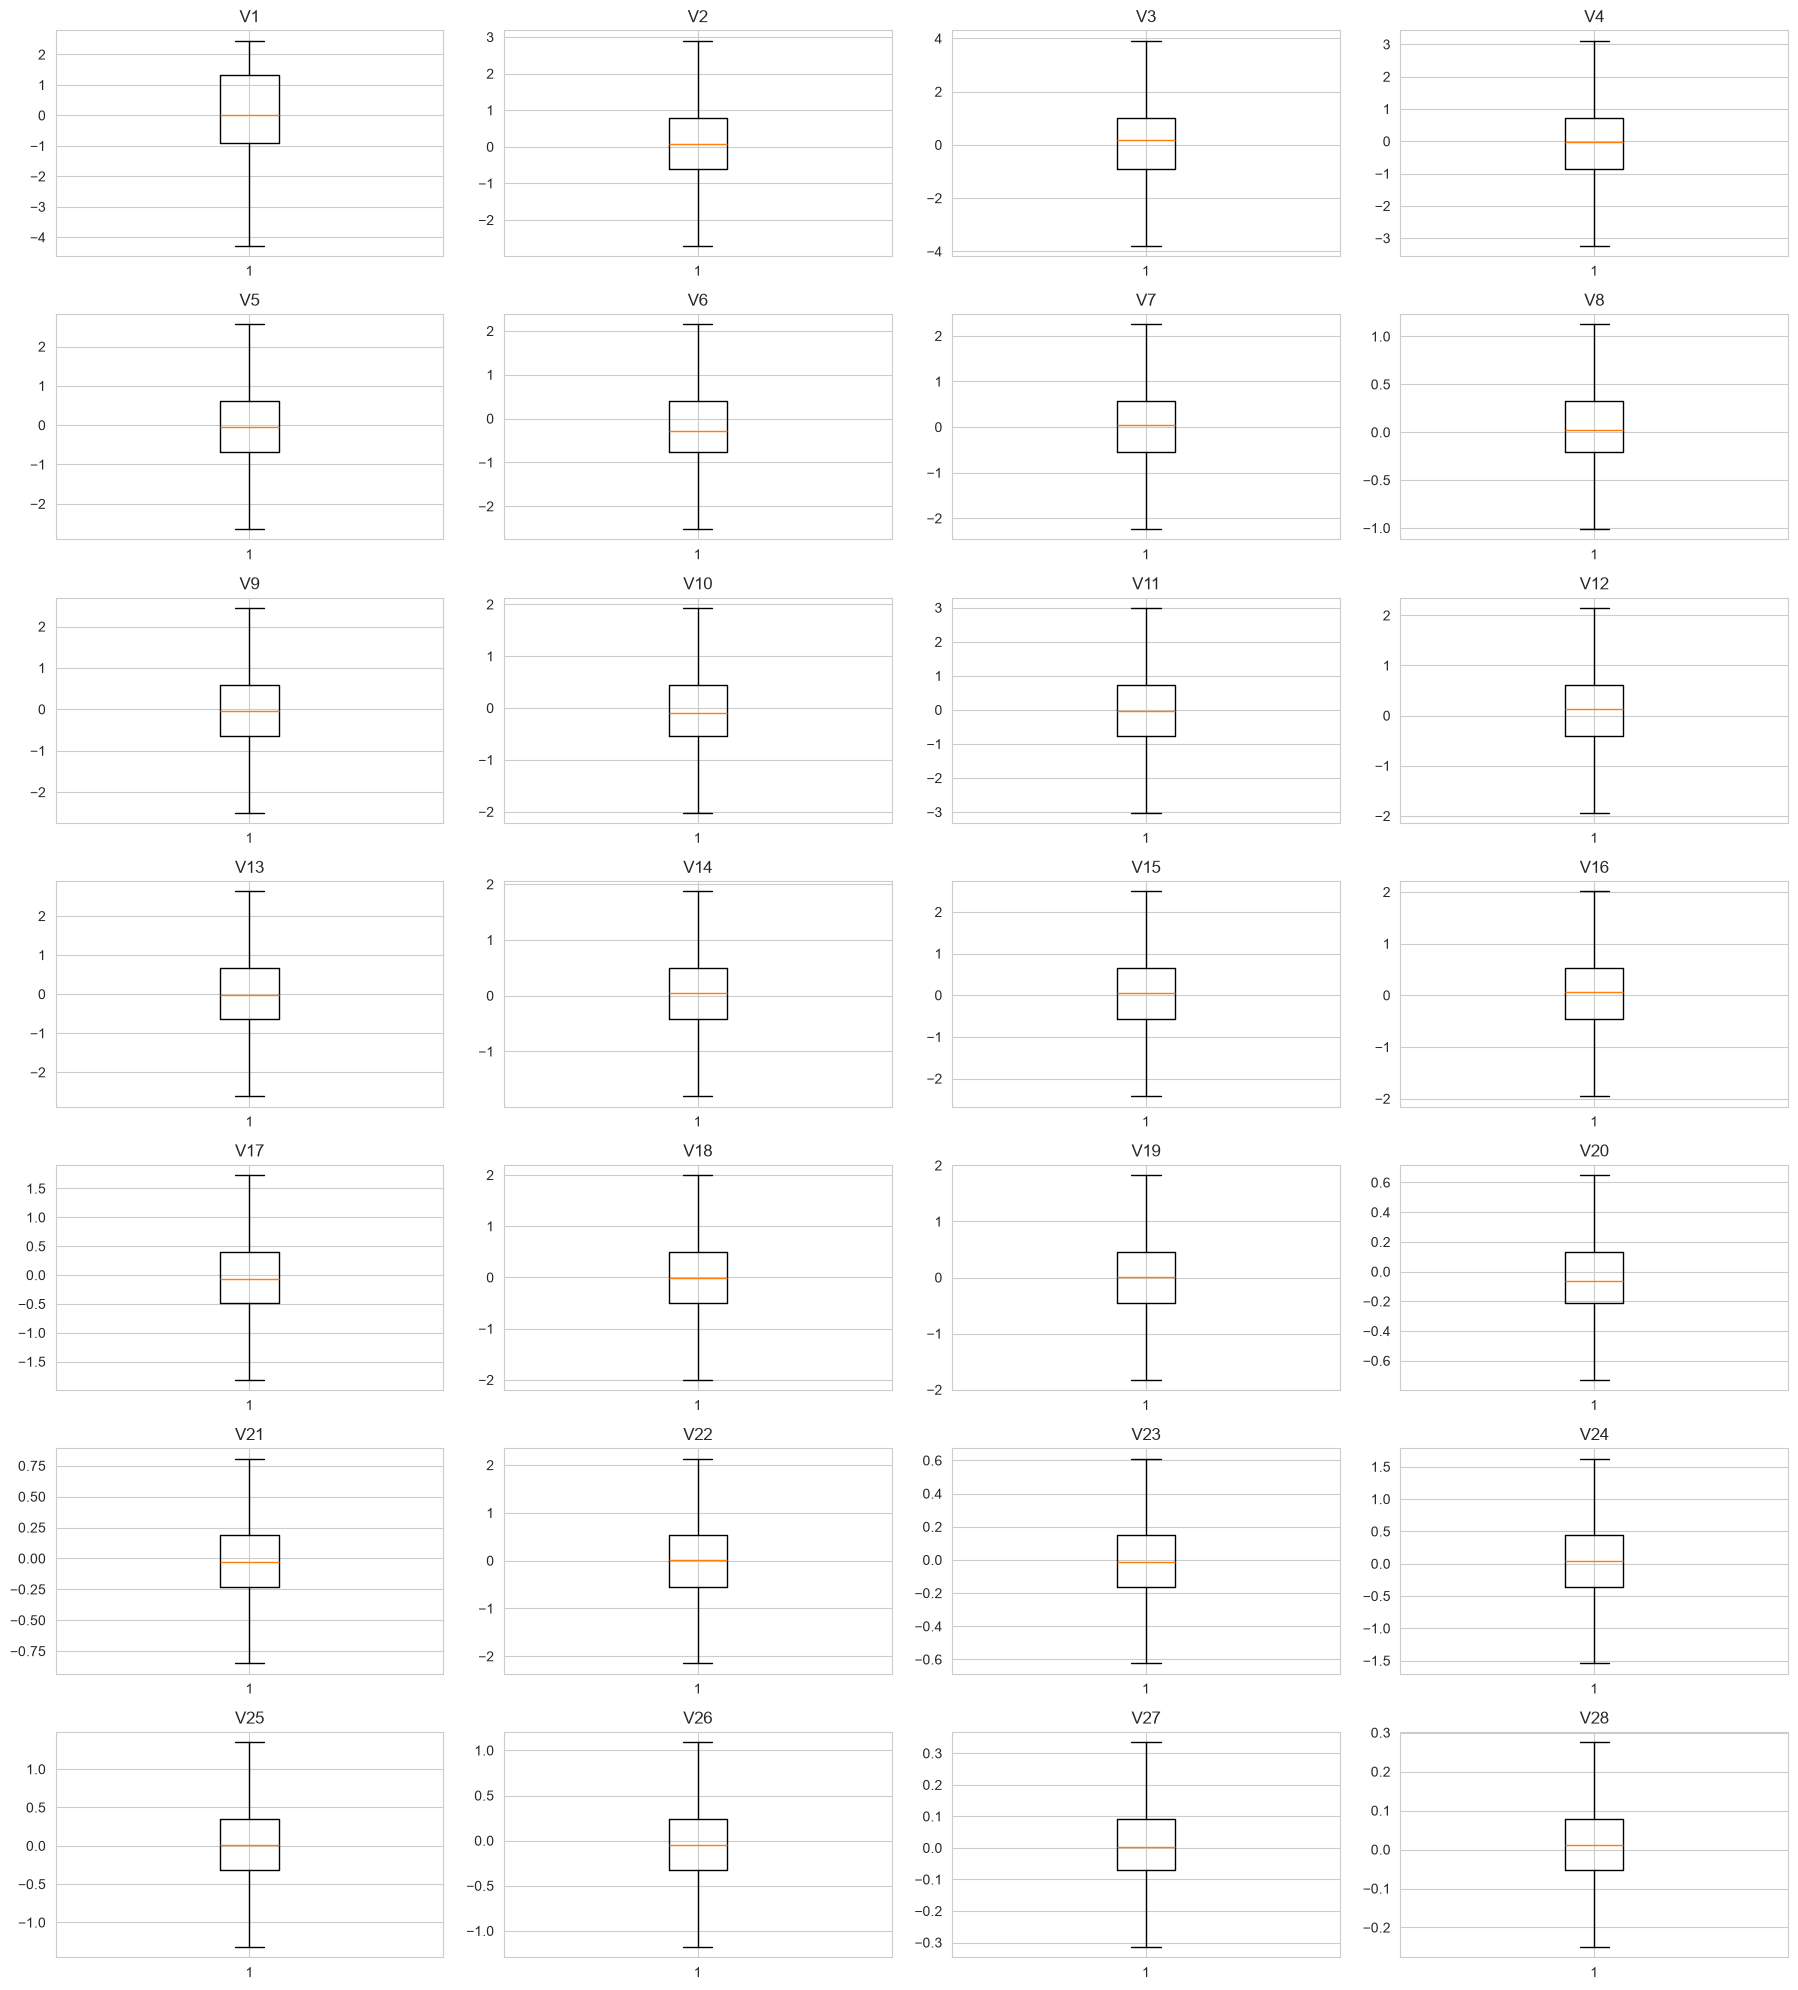

In [501]:
columns = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
        'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
        'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

plt.figure(figsize=(18,20))
for i in range(28):
    plt.subplot(7,4, i+1)
    plt.boxplot(df[columns[i]])
    plt.title(f'{columns[i]}')
    
plt.tight_layout()
plt.show()

In [502]:
columns = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
        'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
        'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

for col in columns:
    print(df[col].skew(), end=', ')

-0.6442376345280258, -0.13547821537568253, -0.4012721111327414, 0.18316356960299007, 0.22593381929244855, 0.6672304777442509, -0.06418759835610267, 0.15127052261772522, 0.0994320455582157, 0.2488056056747036, 0.10240659468343324, -0.56797507268295, 0.0428794062655136, -0.10583775488703465, -0.2563827117669085, -0.23296841326017528, 0.4480723414665863, 0.014613359139437542, -0.03549492585677629, 0.2854765264096729, 0.12376519525189222, -0.03574697854374208, 0.06092276031830052, -0.5424505636323989, -0.15637796301710916, 0.3597841093165824, 0.08719908896716182, -0.027447510728292556, 

* معظم الأعمدة تحتوي على قيم شاذة (Outliers) واضحة.
* الأعمدة V20 و V27 و V28 تحتوي على أكبر عدد من القيم الشاذة
* معظم الأعمدة تتمركز حول الصفر، وده طبيعي لأن البيانات معمولة لها PCA.
* لا يُنصح بحذف الـ Outliers مباشرة، لأن كثيرًا من عمليات الاحتيال تظهر كقيم شاذة، وحذفها قد يؤدي إلى فقدان معلومات مهمة.

### Time Analysis                                               

In [503]:
primary_col_info(df['Time'])

Value Counts Time
3770.0      12
3750.0      11
19900.0     11
3767.0      11
33537.0     10
            ..
111453.0     1
37810.0      1
37952.0      1
6559.0       1
34859.0      1
Name: count, Length: 99277, dtype: int64
Minimum 0.0, Maximum 172792.0
Skewness -0.039512684934525526


**Distribution**

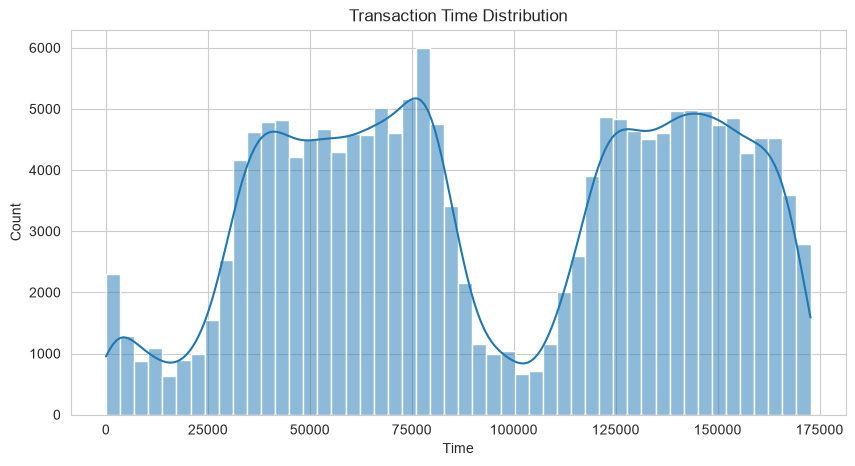

In [504]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Time"],
    bins=50,
    kde=True
)

plt.title("Transaction Time Distribution")
plt.show()

**Time vs Class**

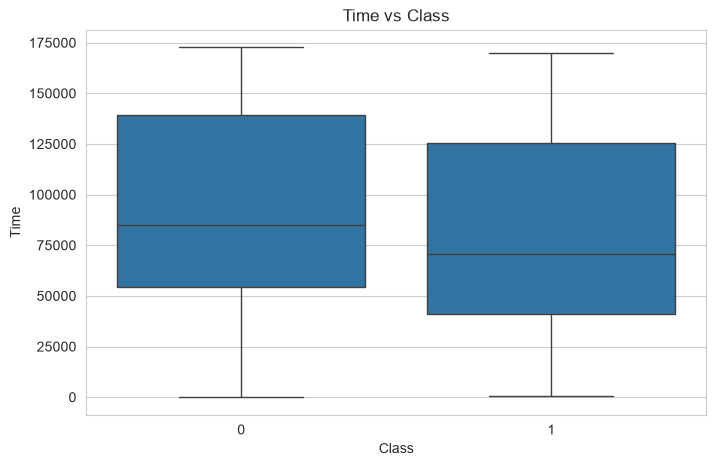

In [505]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Time",
    data=df
)

plt.title("Time vs Class")
plt.show()

In [506]:
max_num_hours = df['Time'].max()/60/60
max_num_hours

np.float64(47.99777777777778)

In [507]:
df['Hours'] = df['Time']/60/60

cols = ['Hours', 'Class']
corr = df[cols].corr()
print(corr)

         Hours    Class
Hours  1.00000 -0.01425
Class -0.01425  1.00000


In [508]:
df.shape

(170436, 32)

In [509]:
df.drop('Time', axis=1, inplace=True)

In [510]:
corr = df.corr()

print(corr.columns)

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class',
       'Hours'],
      dtype='str')


In [511]:
print(df["Class"].head())
print(df["Class"].unique())
print(df["Class"].dtype)

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64
[0 1]
int64


In [512]:
df["Class"].value_counts()

Class
0    170139
1       297
Name: count, dtype: int64

In [513]:


target_corr = corr["Class"].reset_index()

target_corr = target_corr.sort_values(
    by="Class",
    ascending=False
)

target_corr.head(10)

,index,Class
29,Class,1.000000
10,V11,0.095735
3,V4,0.083080
1,V2,0.066700
20,V21,0.047328
26,V27,0.028824
18,V19,0.028427
7,V8,0.027785
19,V20,0.025229
27,V28,0.023617


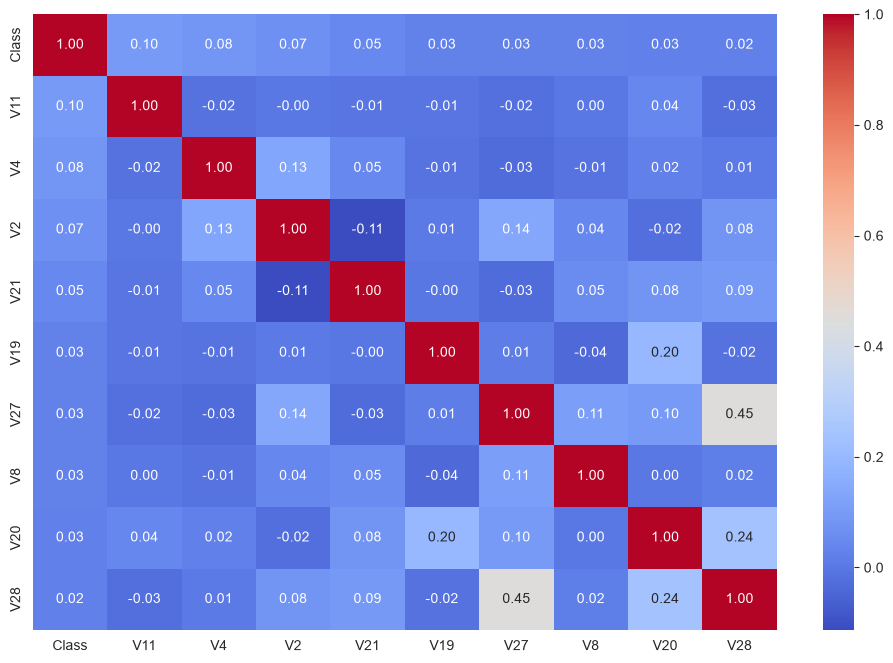

In [514]:
cols = ['Class','V11','V4','V2','V21','V19','V27','V8','V20','V28']
corr = df[cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap= 'coolwarm', annot=True, fmt='.2f')

plt.show()

#### Amount

In [515]:
primary_col_info(df['Amount'])

Value Counts Amount
185.66875    18876
1.00000       8157
1.98000       3600
0.89000       2877
9.99000       2851
             ...  
160.82000        1
168.16000        1
59.67000         1
101.31000        1
182.88000        1
Name: count, Length: 14038, dtype: int64
Minimum 0.0, Maximum 185.66875000000002
Skewness 1.2094776886354253


In [516]:
cols = ['Amount','Class']

corr = df[cols].corr()
print(corr)

          Amount     Class
Amount  1.000000  0.006365
Class   0.006365  1.000000


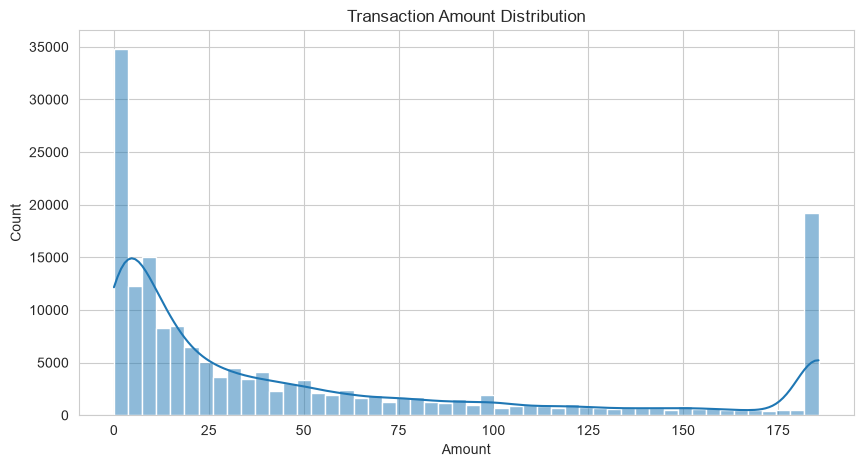

In [517]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.show()

* معظم المعاملات تحتوي على مبالغ صغيرة نسبيًا.
* توزيع قيم المبالغ **منحرف بشدة إلى اليمين (Highly Right-Skewed)**.
* يوجد عدد قليل من المعاملات ذات مبالغ كبيرة جدًا.
* قد يكون من الضروري **تطبيق Scaling (توحيد أو مقياس للبيانات)** قبل تدريب النموذج.


Amount vs Class

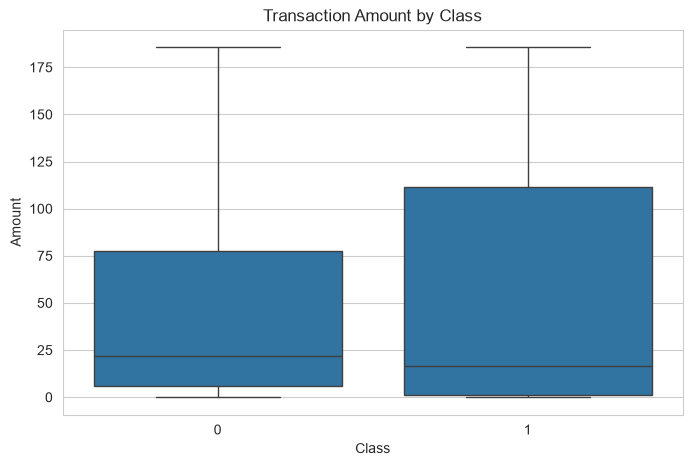

In [518]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Transaction Amount by Class")
plt.show()

In [519]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,170139.0,51.954964,61.893267,0.0,5.69,22.08,77.705,185.66875
1,297.0,61.404306,73.670082,0.0,1.00,16.48,111.700,185.66875


In [521]:
df.groupby("Class")["Amount"].mean()

Class
0    51.954964
1    61.404306
Name: Amount, dtype: float64

#### Conclusion
* The Data is Highly implanced with only 0.00157% positive class
* All featrues (except target) are floats
* Most of the features are Annonymous and normalized, 28 features
* the data is very week (very low correlation)
* there is no missing data (Clean)

#### SO

* We can not use Accurecy as target metric
* We Will use F1-Score as our target metric - also we will try precision, recall, PR-AUC-
* We can do Undersampling majority class
* Oversampling minority class
* Undersampling majority + Oversampling minority
* Tree-based Algorithm